# Comprehensive Systematic Review of Microplastics

This notebook generates all visualizations for the systematic review, including:
- Geographic distribution of study origins (world map)
- Keyword frequency analysis and word cloud
- Top contributing journals (donut chart)
- Sample type distribution map

## Setup

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

nltk.download('punkt',    quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

import os
os.makedirs('images', exist_ok=True)

# Global style
plt.rcParams.update({
    'font.family': 'serif',
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
})

## 1. Geographic Distribution of Study Origins

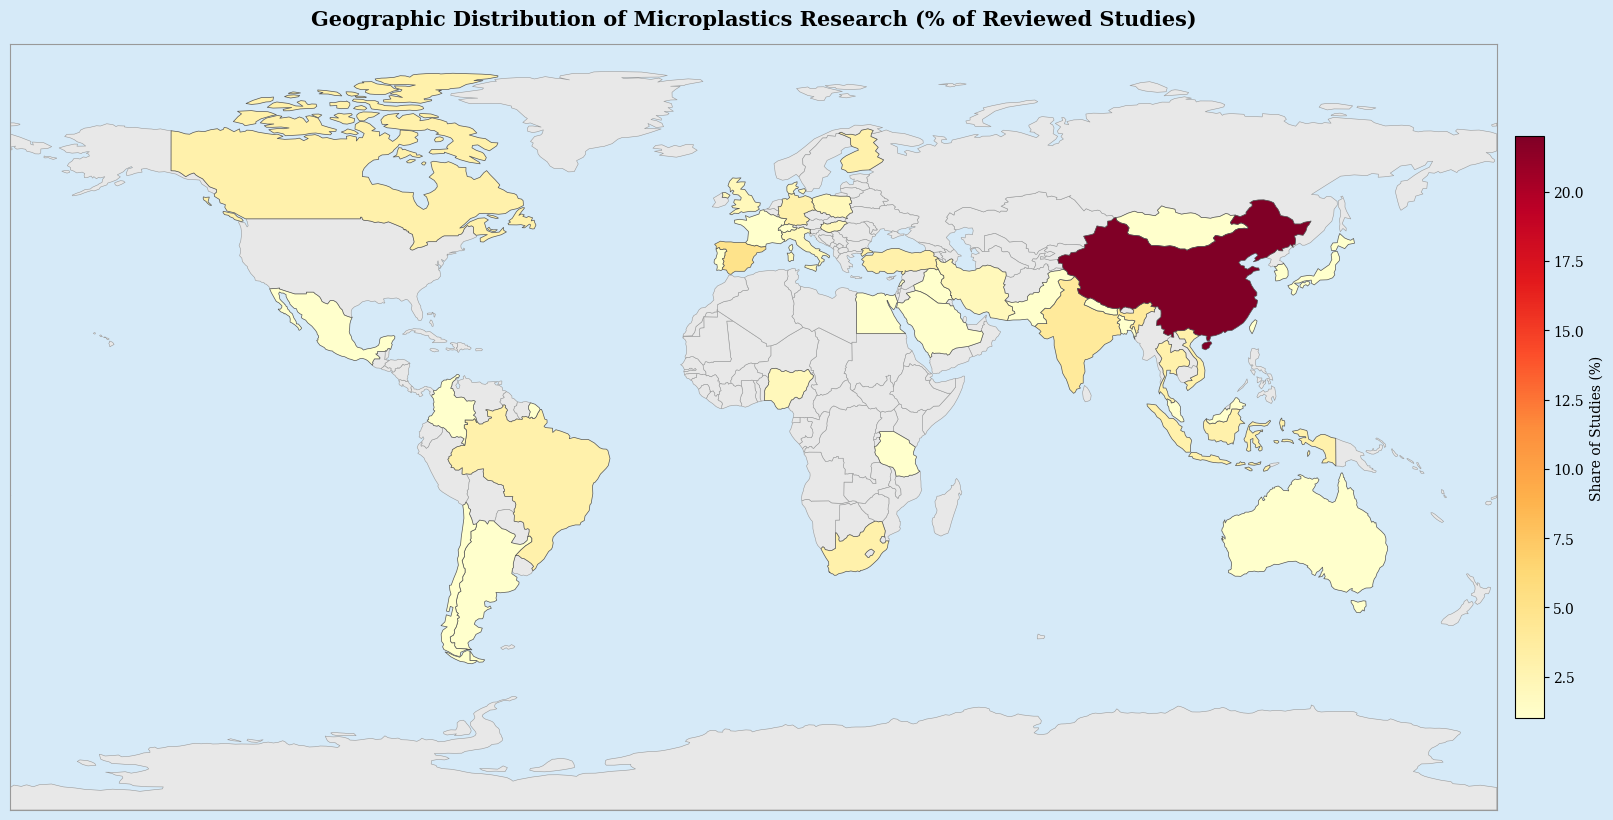

In [2]:
country_percentage = {
    "China": 22, "Saudi Arabia": 1, "USA": 8, "Nigeria": 2,
    "Canada": 3, "Argentina": 1, "Indonesia": 3, "Portugal": 1,
    "Vietnam": 3, "Taiwan": 1, "Nederlands": 3, "South Korea": 1,
    "Italy": 2, "India": 4, "Australia": 1, "Tanzania": 1,
    "Brazil": 3, "Thailand": 3, "Denmark": 2, "Hungary": 2,
    "Colombia": 1, "Pakistan": 1, "Finland": 3, "Mongolia": 1,
    "Spain": 5, "Bangladesh": 1, "Nepal": 1, "United Kingdom": 2,
    "South Africa": 3, "Switzerland": 1, "Japan": 1, "France": 1,
    "Germany": 3, "Hong Kong": 2, "Iran": 2, "Iraq": 1,
    "Chile": 1, "Mexico": 1, "Malaysia": 1, "Turkey": 3,
    "Lebanon": 1, "Egypt": 1, "Poland": 2
}

world = gpd.read_file('data/naturalearth_lowres.geojson')
world['Percentage'] = world['name'].map(country_percentage)

fig, ax = plt.subplots(1, 1, figsize=(18, 10))
fig.patch.set_facecolor('#D6EAF8')   # Ocean colour
ax.set_facecolor('#D6EAF8')

# Background countries (no data)
world[world['Percentage'].isna()].plot(
    ax=ax, color='#E8E8E8', edgecolor='#999999', linewidth=0.4
)

# Countries with data
world_with_data = world.dropna(subset=['Percentage'])
world_with_data.plot(
    column='Percentage',
    cmap='YlOrRd',
    legend=True,
    edgecolor='#555555',
    linewidth=0.5,
    ax=ax,
    legend_kwds={
        'label': 'Share of Studies (%)',
        'shrink': 0.6,
        'aspect': 20,
        'pad': 0.01
    }
)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor('#999999')

ax.set_title(
    'Geographic Distribution of Microplastics Research (% of Reviewed Studies)',
    fontsize=15, fontweight='bold', pad=14
)

plt.tight_layout()
plt.savefig('images/world_map.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Keyword Frequency Analysis

In [3]:
with open('keywords.txt', 'r') as f:
    text = f.read()

tokens = word_tokenize(text)
stop_words = set(stopwords.words('english'))
keywords = [
    word.lower() for word in tokens
    if word.isalnum() and word.lower() not in stop_words
]

lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(w) for w in keywords]
keyword_freq = Counter(lemmatized)

top50 = keyword_freq.most_common(50)
print('Top 50 keywords:')
for term, count in top50:
    print(f'  {term}: {count}')

Top 50 keywords:
  microplastics: 26
  pollution: 11
  health: 10
  human: 8
  plastic: 8
  microplastic: 8
  aquatic: 7
  water: 6
  environmental: 6
  marine: 5
  treatment: 5
  toxicity: 5
  method: 4
  effect: 4
  organic: 4
  impact: 4
  drinking: 3
  emerging: 3
  detection: 3
  environment: 3
  mitigation: 3
  source: 3
  ecosystem: 3
  food: 3
  air: 2
  fiber: 2
  pollutant: 2
  life: 2
  cycle: 2
  assessment: 2
  factor: 2
  waste: 2
  strategy: 2
  characterization: 2
  wastewater: 2
  sea: 2
  plant: 2
  technology: 2
  gut: 2
  microbiota: 2
  migration: 2
  persistent: 2
  fate: 2
  transport: 2
  organism: 2
  physiology: 2
  analytical: 2
  matter: 2
  membrane: 2
  freshwater: 2


## 3. Keyword Word Cloud

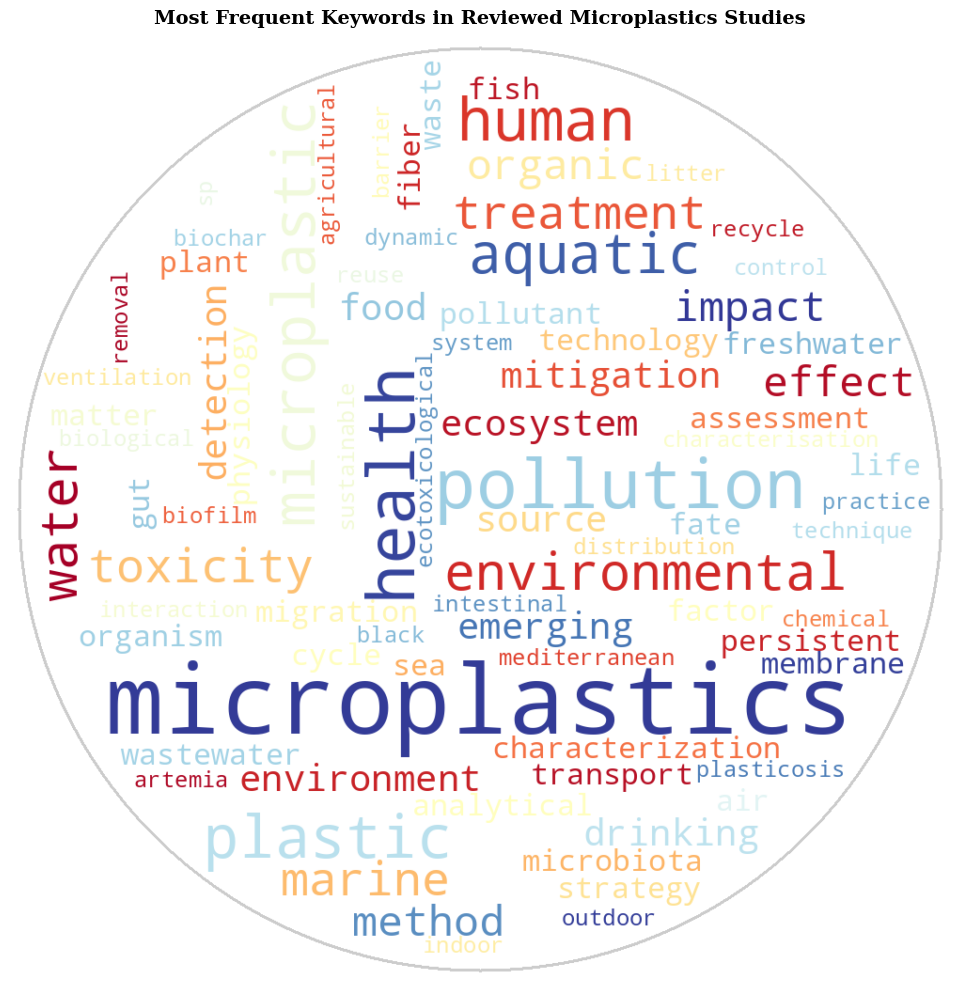

In [4]:
x, y = np.ogrid[:1000, :1000]
mask = (x - 500) ** 2 + (y - 500) ** 2 > 490 ** 2
mask = 255 * mask.astype(np.uint8)

wordcloud = WordCloud(
    width=1000, height=1000,
    background_color='white',
    mask=mask,
    colormap='RdYlBu_r',
    contour_width=2,
    contour_color='#cccccc',
    max_words=80,
    prefer_horizontal=0.85,
    min_font_size=10,
).generate_from_frequencies(keyword_freq)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title(
    'Most Frequent Keywords in Reviewed Microplastics Studies',
    fontsize=14, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig('images/wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Top Contributing Journals

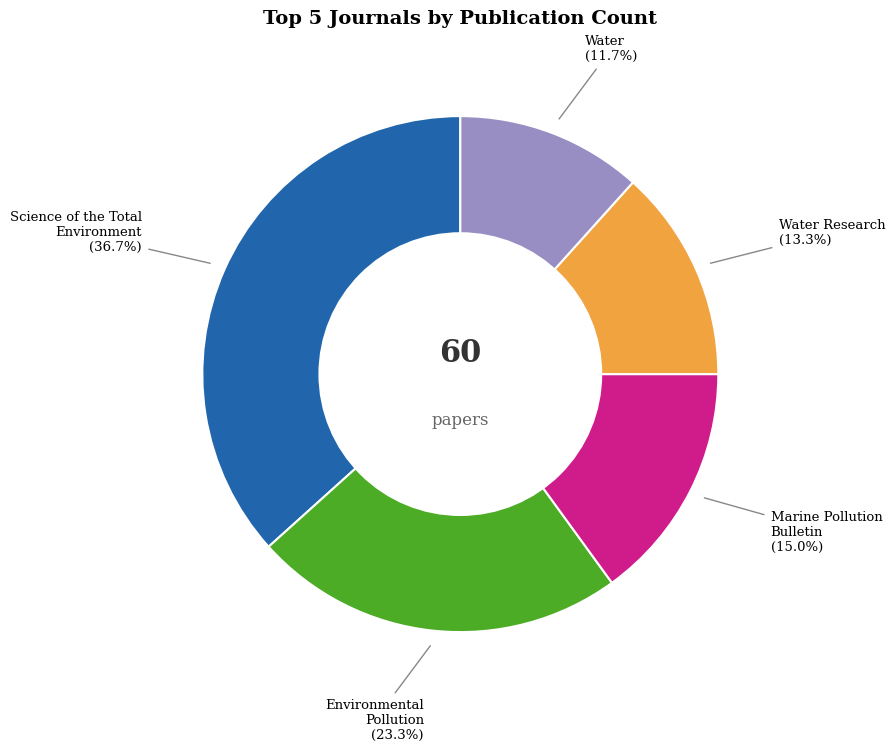

In [5]:
journals = [
    "Science of the Total\nEnvironment",
    "Environmental\nPollution",
    "Marine Pollution\nBulletin",
    "Water Research",
    "Water"
]
counts = [22, 14, 9, 8, 7]
total = sum(counts)

colors = ['#2166ac', '#4dac26', '#d01c8b', '#f1a340', '#998ec3']

fig, ax = plt.subplots(figsize=(9, 9))

wedges, texts = ax.pie(
    counts,
    labels=None,
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
    radius=1.0
)

# Donut hole
centre_circle = plt.Circle((0, 0), 0.55, color='white', linewidth=0)
ax.add_patch(centre_circle)

# Centre label
ax.text(0, 0.08, f'{total}', ha='center', va='center',
        fontsize=22, fontweight='bold', color='#333333')
ax.text(0, -0.18, 'papers', ha='center', va='center',
        fontsize=12, color='#666666')

# External labels with leader lines
for i, (wedge, journal, count) in enumerate(zip(wedges, journals, counts)):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x_mid = np.cos(np.radians(angle))
    y_mid = np.sin(np.radians(angle))
    x_text = 1.35 * x_mid
    y_text = 1.35 * y_mid
    pct = count / total * 100
    ha = 'left' if x_mid > 0 else 'right'
    ax.annotate(
        f'{journal}\n({pct:.1f}%)',
        xy=(x_mid * 1.05, y_mid * 1.05),
        xytext=(x_text, y_text),
        ha=ha, va='center',
        fontsize=9.5,
        arrowprops=dict(arrowstyle='-', color='#888888', lw=1.0),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.8)
    )

ax.set_title(
    'Top 5 Journals by Publication Count',
    fontsize=14, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('images/journal_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Sample Type Distribution Map

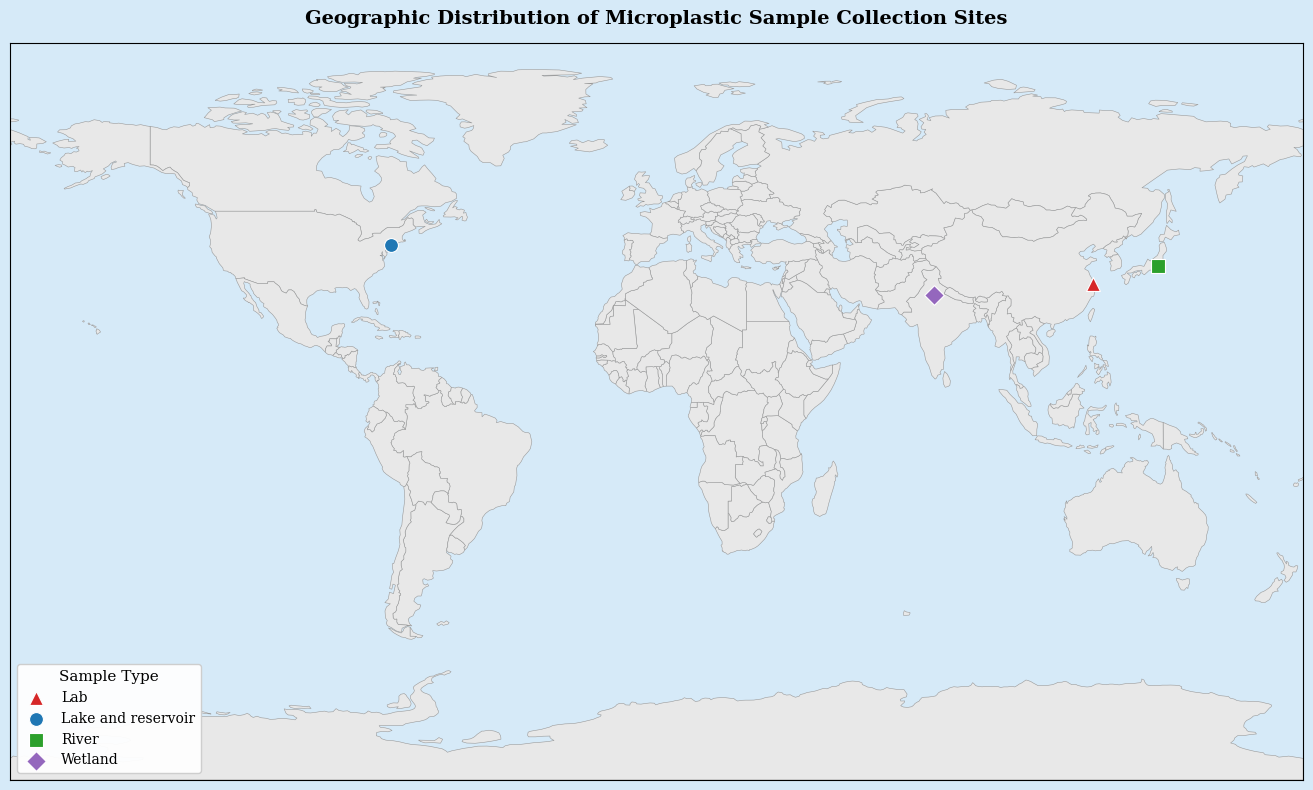

In [6]:
world = gpd.read_file('data/naturalearth_lowres.geojson')

# Sample collection sites from reviewed studies
data = pd.DataFrame({
    'Latitude':   [40.7128,  31.2304,   35.6895,   28.6139],
    'Longitude':  [-74.0060, 121.4737,  139.6917,  77.2090],
    'Sample Type': ['Lake and reservoir', 'Lab', 'River', 'Wetland']
})

gdf = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data.Longitude, data.Latitude),
    crs='EPSG:4326'
)

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#D6EAF8')
ax.set_facecolor('#D6EAF8')

world.plot(ax=ax, color='#E8E8E8', edgecolor='#999999', linewidth=0.4)

palette = {'Lake and reservoir': '#1f77b4',
           'Lab':               '#d62728',
           'River':             '#2ca02c',
           'Wetland':           '#9467bd'}
marker_map = {'Lake and reservoir': 'o',
              'Lab':               '^',
              'River':             's',
              'Wetland':           'D'}

for st, group in gdf.groupby('Sample Type'):
    group.plot(
        ax=ax,
        color=palette[st],
        marker=marker_map[st],
        markersize=100,
        label=st,
        zorder=5,
        edgecolor='white',
        linewidth=0.8
    )

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xticks([])
ax.set_yticks([])

legend = ax.legend(
    title='Sample Type', loc='lower left',
    framealpha=0.95, fontsize=10,
    title_fontsize=11, edgecolor='#cccccc'
)

ax.set_title(
    'Geographic Distribution of Microplastic Sample Collection Sites',
    fontsize=14, fontweight='bold', pad=14
)

plt.tight_layout()
plt.savefig('images/sample_type_map.png', dpi=300, bbox_inches='tight')
plt.show()